# Ejercicio 5
* Considerar una poblaci´on de animales costeros, que viven entre las l´ıneas de mareas alta y baja
(“intertidal”). Estas poblaciones son particularmente vulnerables al efecto de tormentas severas, que
las afectan de distinto modo seg´un su intensidad y el estado de la marea. Supongamos que puede
modelar el sistema mediante una evoluci´on determinista entre eventos desastrosos que ocurren al azar:
  * (a) Crecimiento logístico entre desastres: $dN/dt = rN (1 − N=K)$.
  * (b) Si ocurre un desastre a tiempo t, inmediatamente la poblaci´on se ve reducida en una fraccion p: $N (t+) = pN (t)$.
  * (c) Los tiempos entre desastres siguen una distribucion exponencial con media $1/\lambda$ (es decir la ocurrencia de desastres es un proceso de Poisson, con tasa $\lambda$). Analizar el    comportamiento del sistema y encontrar una condici´on que caracterice la posibilidad del sistema de recuperarse de un desastre.

In [1]:
import numpy as np 
import scipy as sci
import os
import math
from numpy import random
from scipy.integrate import odeint
from scipy.stats import poisson
from matplotlib import pyplot as plt
from matplotlib.ticker import AutoMinorLocator
from matplotlib.ticker import MultipleLocator

In [2]:
def sol_logistic(K, N0, r, t):
    """Función que devuelve la solución a la ecuación logistica
    Args:
        K: Capacidad
        N0: Población inicial
        r: Tasa de crecimiento
        t: Tiempo
    Returns:
        N: Población en el tiempo t
    """
    return (K * N0 * math.exp(r * t) )/ (K + N0 * (math.exp(r * t) - 1))

In [17]:
# Creamos el vector de tiempos y de población
t = np.arange(0, 20, 0.1)
N = np.zeros_like(t)

In [18]:
def catastrofe_poisson(N, lamb = 1.0):
    """Función que se evalúa tiempo a timepo para simular una catástrofe
    Args:
        lamb: Tasa de catástrofe
    Returns:
        N: Población en el tiempo t reducida por la catástrofe
    """
    pass

In [24]:
events = np.random.exponential(1/0.5, 10)
ts = np.cumsum(events)
print(np.unique(np.round(ts)))

[ 4.  5.  9. 11. 12. 13. 18. 19.]


In [25]:
# Creamos el vector de tiempos y de población
t = np.arange(0, 20, 0.1)
lamb = 0.5 # Numero de catástrofes por unidad de tiempo
p = 0.5 # Porcentaje de la población que sobrevive a la catástrofe
K = 100 # Capacidad
r = 0.3 # Tasa de crecimiento
N0 = 10 # Población inicial

for i, ti in enumerate(t):
    N[i] = sol_logistic(K, N0, r, ti)
    if round(N[i]) == 0: # Si la población se extingue, terminamos
        break

    if i in np.unique(np.round(ts)):
        N[i] = N[i] * p
        N0 = N[i]
    # if random.rand() < lamb and i+1 < len(t): # Esto simula el proceso de posisson, un numero random entre 0 y 1, si es menor a la tasa de catástrofe, se aplica la catástrofe
    #     N[i+1] = N[i] * p
    #     N0 = N[i+1]
    else:
        N0 = N[i]
print(len(N))

200


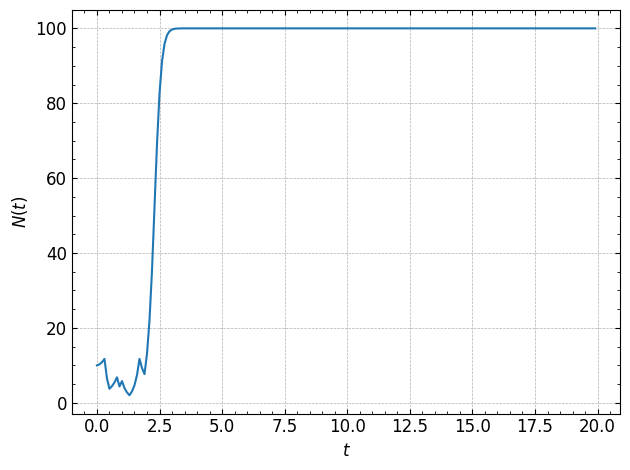

In [26]:
plt.plot(t, N)
plt.xlabel('$t$', fontsize = 12)
plt.ylabel('$N(t)$', fontsize = 12)
plt.gca().xaxis.set_major_locator(plt.AutoLocator())
plt.gca().xaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_major_locator(plt.AutoLocator())
plt.gca().yaxis.set_minor_locator(AutoMinorLocator())
plt.gca().yaxis.set_ticks_position('both')
plt.gca().xaxis.set_ticks_position('both')
plt.tick_params(axis='both', which='both', direction='in', top=True, right=True, labelsize=12)
plt.grid(linestyle='--', linewidth=0.5)
plt.tight_layout()
# save_path = r"C:\Users\Propietario\Desktop\ib\5-Maestría\Matematica de los sistemas biológicos\Practica_1\Practico\Ej05"
# plt.savefig(os.path.join(save_path, "CatastrofesPoblacionExtincion.pdf"))
plt.show()

Vemos que en este caso la población sobrevive a los desastres aunque se ve reducida en una fracción p vuelve a crecer de manera logística hasta el próximo desastre.
Puede ocurrir también el caso en que la población se extinga. Acá supusimos puramente que la población es continua aunque el tratamiento para poblaciones pequeñas debería tratarse de manera discreta con Beberton-Holt. Busquemos ahora como caracterizar si la población sobrevive o no a la catástrofe.